## MDE Application to Fly Neural Data

### Drosophila melanogaster

A fly expressing the calcium indicator GCaMP6f as a measure of neuronal activity was
recorded walking on a Styrofoam ball. Neuronal activity was segmented by independent
component analysis (ICA) yielding 80 component brain areas. Two behavioral
variables were simultaneously recorded: forward speed (FWD) and left/right turning
speed (Left Right). 

Find MDE of neural activity to forward movement. 

### Import modules

In [1]:
from pandas     import read_csv, DataFrame
from matplotlib import pyplot as plt
%matplotlib ipympl

These modules are required for the`Evaluate()`function to compare MDE results. 

In [2]:
import numpy
import sklearn
import pydiffmap

#### Import MDE & Evaluate classes

In [3]:
from dimx import MDE, Evaluate

---

#### Read Drosophila data

In [4]:
df = read_csv( './data/Fly80XY_norm_1061.csv' )

#### Instantiate and Run MDE class objects for FWD & Left_Right targets
We use the first 300 time series rows to create the EDM library, and perform out-of-sample prediction on time series rows 301-600. These indices are Not zero offset. 

`ccmSlope` is the minimum slope of a linear fit to the CCM rho(L) curve to validate a causal driver. L is the vector of CCM library sizes at which CCM is evaluated. Default values for L are percentiles [10,15,85,90] of the number of observations (rows).

In [5]:
Fly_FWD = MDE( df,                     # Pandas DataFrame of observables
               target = 'FWD',         # target behavior variable
               removeColumns = ['index','FWD','Left_Right'], # variables to ignore
               D    = 12,              # Max number of dimensions
               lib  = [1,300],         # EDM library start,stop indices
               pred = [301,600],       # EDM prediction start,stop indices
               ccmSlope = 0.01,        # CCM convergence criteria
               embedDimRhoMin = 0.65,  # Minimum rho for CCM embedding dimension
               crossMapRhoMin = 0.5,   # Minumum rho for cross map of target : variables
               plot = False )
Fly_FWD.Run()

Run() warning: ccmSeed is None; CCM uses random library samples, so cached slopes will not match a recompute. Set ccmSeed to a fixed integer for reproducible selection.


In [6]:
Fly_LR = MDE( df,
              target = 'Left_Right',
              removeColumns = ['index','FWD','Left_Right'], 
              D    = 12,
              lib  = [1,600],
              pred = [801,1000], 
              ccmSlope = 0.01,
              embedDimRhoMin = 0.2,
              crossMapRhoMin = 0.05,
              plot = False )
Fly_LR.Run()

Run() warning: ccmSeed is None; CCM uses random library samples, so cached slopes will not match a recompute. Set ccmSeed to a fixed integer for reproducible selection.


---

#### Combine FWD & Left_Right results into one DataFrame and plot

In [7]:
FlyDF = DataFrame( 
    {'D' : [i for i in range(1, len(Fly_FWD.MDEOut)+1)],
     'FWD_variable':Fly_FWD.MDEOut['variables'], 'FWD_rho':Fly_FWD.MDEOut['rho'], 
     'LR_variable' :Fly_LR.MDEOut['variables'],  'LR_rho' :Fly_LR.MDEOut['rho'] } )

In [8]:
FlyDF

,D,FWD_variable,FWD_rho,LR_variable,LR_rho
0,1,TS33,0.652844,TS26,0.197529
1,2,TS4,0.792290,TS67,0.568969
2,3,TS8,0.819050,TS69,0.599104
3,4,TS9,0.839394,TS65,0.685190
4,5,TS32,0.859089,TS71,0.686665
5,6,TS24,0.860191,TS60,0.706212
6,7,TS26,0.869044,TS53,0.769066
7,8,TS71,0.871098,TS79,0.770243
8,9,TS23,0.861370,TS76,0.745978
9,10,TS44,0.855469,TS57,0.726474


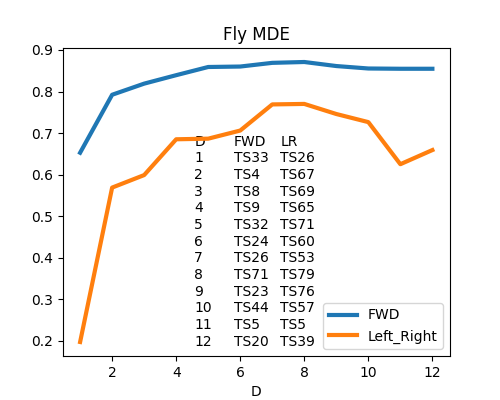

In [9]:
ax = FlyDF.plot( x = 'D', y=['FWD_rho','LR_rho'], label = ['FWD','Left_Right'],
                 lw = 3, figsize = (5,4), title = 'Fly MDE' )
table = ax.table( cellText = FlyDF.loc[:,['D','FWD_variable','LR_variable']].values,
                  colLabels = ['D','FWD','LR'], loc = 'lower center', fontsize = 10,
                  colWidths = [0.1,0.12,0.12], edges = 'open', colLoc = 'left', cellLoc = 'left' )

MDE indicates forward motion can be represented with a 5-dimensional embedding of observation vectors TS33, TS4, TS8, TS9, TS32. These 5 variables achieve a Pearson correlation of 0.86 between observed and predicted forward movement. 

---

#### Evaluate MDE components & compare to PCA & Diffusion Map

Here we compare out-of-sample prediction of FWD behavior with the 5 MDE identified observables as well as 5 component PCA and Diffusion Map. 

	MDE:  CAE 35.37  RMSE 0.183  R 0.85  R^2 0.722
	PCA:  CAE 53.25  RMSE 0.212  R 0.802  R^2 0.643
	dMap: CAE 47.24  RMSE 0.219  R 0.77  R^2 0.593


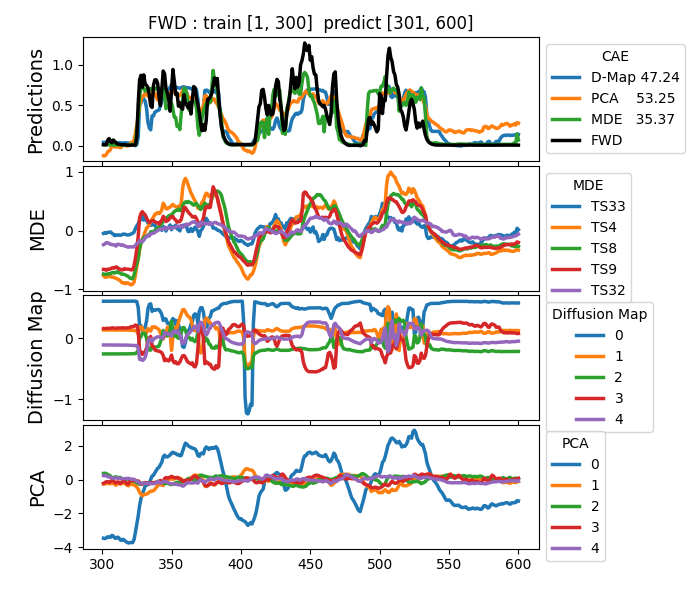

In [10]:
Fly_FWD_Eval = Evaluate( df, 
                         columns_range = [1,81], # 0-offset range of columns for PCA, DMap
                         mde_columns = ['TS33', 'TS4', 'TS8', 'TS9', 'TS32'],
                         predictVar = 'FWD',
                         library    = [1, 300],   # index start,stop of observations for library
                         prediction = [301, 600], # index start,stop of predictions 
                         components = 5,          # Number of PCA & DMap components
                         dmap_k     = 15,         # diffusion_map k nearest neighbors
                         figsize    = (7,6) )
Fly_FWD_Eval.Run()
Fly_FWD_Eval.Plot()

The MDE prediction has the lowest CAE (cumulative absolute error) to the out-of-sample observations. The diffusion map compoents are latent (not observable) and do not correspond in an obvious way to observed neural dynamics. The PCA prediction lumps the majority of the variance into a single component based on a linear decomposition. Both PCA and diffusion map predict activity during times when no FWD movement is observed, while MDE does not. Crucially, MDE predictions are not latent, but actual _observables_ of the system.

---